# 🧠 Introducción: Explorando el dataset de granos de arroz con PCA

En este cuaderno vamos a trabajar con un conjunto de datos que contiene mediciones físicas de granos de arroz pertenecientes a distintas variedades.
Cada fila representa un grano individual, y cada columna describe una característica morfológica (por ejemplo, área, perímetro o excentricidad).
El objetivo es analizar si esas variables permiten diferenciar las clases de arroz y, al mismo tiempo, aplicar Análisis de Componentes Principales (PCA) para simplificar el conjunto de variables sin perder información relevante.



---



📦 Sobre el dataset

El dataset contiene 3810 observaciones y 8 columnas:

* Área: superficie total del grano.

* Perímetro: longitud del contorno.

* Longitud del eje mayor: largo máximo del grano.

* Longitud del eje menor: ancho máximo.

* Excentricidad: mide cuán alargado es el grano (similaridad con una elipse).

* Área convexa: área de la figura convexa mínima que contiene el grano.

* Extensión: proporción del área ocupada respecto al área total del contorno.

* Clase: variedad de arroz (variable categórica que distingue los tipos).

En este conjunto de datos tenemos dos tipos:

Osmancik:
Es una variedad de arroz de grano medio cultivada principalmente en Turquía.
Sus granos son algo más largos y alargados, con menor excentricidad (más ovalados).
Se caracteriza por tener una textura ligeramente más suelta al cocinarse.

Cammeo:
Es una variedad italiana de arroz de grano corto y redondeado, muy usada para risotto.
Sus granos tienden a ser más anchos y con mayor área convexa en comparación con Osmancik.

Todas las variables, excepto la clase, son numéricas y continuas, derivadas de análisis de imagen de los granos.



---




🎯 ¿Qué queremos lograr?

Aunque podríamos usar estas variables para construir un modelo de clasificación supervisado (predecir la clase del arroz), en este caso vamos a centrarnos en un análisis exploratorio no supervisado, aplicando PCA.

El objetivo del PCA será:

1. Reducir la cantidad de variables manteniendo la mayor parte de la información.

2. Identificar patrones y relaciones entre las medidas.

3. Visualizar los datos en pocas dimensiones (2D o 3D) para entender si las clases se diferencian naturalmente.

Esto es muy útil en problemas donde las variables están correlacionadas (por ejemplo, el área, el perímetro y las longitudes), ya que el PCA puede condensar esa información redundante en un número menor de componentes principales.



---




💬 ¿Por qué usar PCA en este caso?

1. Las variables están correlacionadas:
En granos de arroz, un grano grande tiende a tener área, perímetro y longitudes mayores.
Es decir, muchas variables describen aspectos similares del tamaño o la forma.
PCA puede eliminar esa redundancia, creando nuevas variables (componentes) independientes entre sí.

2. Queremos visualizar en 2D o 3D:
Como tenemos 7 variables numéricas, es difícil imaginar su estructura.
Con PCA, podemos representar la mayoría de la información en solo 2 o 3 dimensiones, facilitando la exploración visual y la interpretación.

3. Queremos entender la estructura antes de clasificar:
PCA nos ayuda a ver si las clases naturales (tipos de arroz) ya están separadas en el espacio de las variables originales o si se superponen mucho.
Esto nos da una idea de qué tan bien podrían funcionar futuros modelos supervisados.

# Bibliotecas a utilizar en el cuaderno

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from plotly import subplots


from scipy import stats
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from sklearn import metrics




# Creación de un dataframe a partir del archivo csv

In [2]:
dfRice = pd.read_csv('https://docs.google.com/spreadsheets/d/e/2PACX-1vR2JTCQKzRmjSJBUvu7OOrcBceJcdVbyU1NMdzbThKKcEgiJQ55PH1AfpzQGvbAV1Om6uz-PsOrgn5i/pub?gid=521645460&single=true&output=csv')

#Visualización del segmento inicial y final de los datos

In [3]:
dfRice

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Class
0,15231,525.578979,229.749878,85.093788,0.928882,15617,0.572896,Cammeo
1,14656,494.311005,206.020065,91.730972,0.895405,15072,0.615436,Cammeo
2,14634,501.122009,214.106781,87.768288,0.912118,14954,0.693259,Cammeo
3,13176,458.342987,193.337387,87.448395,0.891861,13368,0.640669,Cammeo
4,14688,507.166992,211.743378,89.312454,0.906691,15262,0.646024,Cammeo
...,...,...,...,...,...,...,...,...
3805,11441,415.858002,170.486771,85.756592,0.864280,11628,0.681012,Osmancik
3806,11625,421.390015,167.714798,89.462570,0.845850,11904,0.694279,Osmancik
3807,12437,442.498993,183.572922,86.801979,0.881144,12645,0.626739,Osmancik
3808,9882,392.296997,161.193985,78.210480,0.874406,10097,0.659064,Osmancik


# Preprocesamiento

###Renombraremos las columnas al español

In [4]:
#Renombrado de columnas
dfRice.rename({'Perimeter':'Perimetro',
           'Major_Axis_Length':'Longitud_Eje_Mayor',
           'Minor_Axis_Length':'Longitud_Eje_Menor',
           'Eccentricity':'Excentricidad',
           'Convex_Area':'Area_Convexa',
           'Extent':'Extension',
           'Class':'Clase'},
          axis=1, inplace=True) # inplace = True para que el renombrado sea sobre el mismo df

##dfRice.drop('Id', axis=1, inplace=True) #axis=1 indica que es una columna


In [5]:
dfRice

,Area,Perimetro,Longitud_Eje_Mayor,Longitud_Eje_Menor,Excentricidad,Area_Convexa,Extension,Clase
0,15231,525.578979,229.749878,85.093788,0.928882,15617,0.572896,Cammeo
1,14656,494.311005,206.020065,91.730972,0.895405,15072,0.615436,Cammeo
2,14634,501.122009,214.106781,87.768288,0.912118,14954,0.693259,Cammeo
3,13176,458.342987,193.337387,87.448395,0.891861,13368,0.640669,Cammeo
4,14688,507.166992,211.743378,89.312454,0.906691,15262,0.646024,Cammeo
...,...,...,...,...,...,...,...,...
3805,11441,415.858002,170.486771,85.756592,0.864280,11628,0.681012,Osmancik
3806,11625,421.390015,167.714798,89.462570,0.845850,11904,0.694279,Osmancik
3807,12437,442.498993,183.572922,86.801979,0.881144,12645,0.626739,Osmancik
3808,9882,392.296997,161.193985,78.210480,0.874406,10097,0.659064,Osmancik


###Inspección de la forma del df

In [6]:
dfRice.shape

(3810, 8)

###Analizaremos la cantidad de instancias de cada clase

In [7]:
dfRice['Clase'].value_counts()

,count
Clase,
Osmancik,2180
Cammeo,1630


Las clases estan balanceadas.

###Veamos la información general del dataset

In [8]:
dfRice.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3810 entries, 0 to 3809
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Area                3810 non-null   int64  
 1   Perimetro           3810 non-null   float64
 2   Longitud_Eje_Mayor  3810 non-null   float64
 3   Longitud_Eje_Menor  3810 non-null   float64
 4   Excentricidad       3810 non-null   float64
 5   Area_Convexa        3810 non-null   int64  
 6   Extension           3810 non-null   float64
 7   Clase               3810 non-null   object 
dtypes: float64(5), int64(2), object(1)
memory usage: 238.3+ KB


3810 instancias.
Tiene 8 variables, la última es el tipo de arroz, si fueramos a clasificar sería la variable objetivo.
Las 7 primeras variables de entrada son numéricas y no tienen elementos nulos, serán las que utilizaremos para el análisis de componentes principales

###Obtenemos los principales indicadores estadísticos de las variables del dataset

In [9]:
dfRice.describe()

,Area,Perimetro,Longitud_Eje_Mayor,Longitud_Eje_Menor,Excentricidad,Area_Convexa,Extension
count,3810.000000,3810.000000,3810.000000,3810.000000,3810.000000,3810.000000,3810.000000
mean,12667.727559,454.239180,188.776222,86.313750,0.886871,12952.496850,0.661934
std,1732.367706,35.597081,17.448679,5.729817,0.020818,1776.972042,0.077239
min,7551.000000,359.100006,145.264465,59.532406,0.777233,7723.000000,0.497413
25%,11370.500000,426.144752,174.353855,82.731695,0.872402,11626.250000,0.598862
50%,12421.500000,448.852493,185.810059,86.434647,0.889050,12706.500000,0.645361
75%,13950.000000,483.683746,203.550438,90.143677,0.902588,14284.000000,0.726562
max,18913.000000,548.445984,239.010498,107.542450,0.948007,19099.000000,0.861050


* Ninguna variable tiene datos en 0.
* Los valores no estan en la misma escala, por lo tanto tendremos que estandarizarlos

# Análisis exploratorio

Antes de aplicar PCA, es importante conocer el comportamiento de las variables originales.
Revisaremos sus distribuciones, presencia de valores extremos (outliers) y correlaciones entre variables.
Esto es fundamental porque el PCA se basa en la varianza y la covarianza de los datos, por lo tanto, los valores atípicos o las escalas diferentes pueden distorsionar los resultados.

## Análisis Univariado

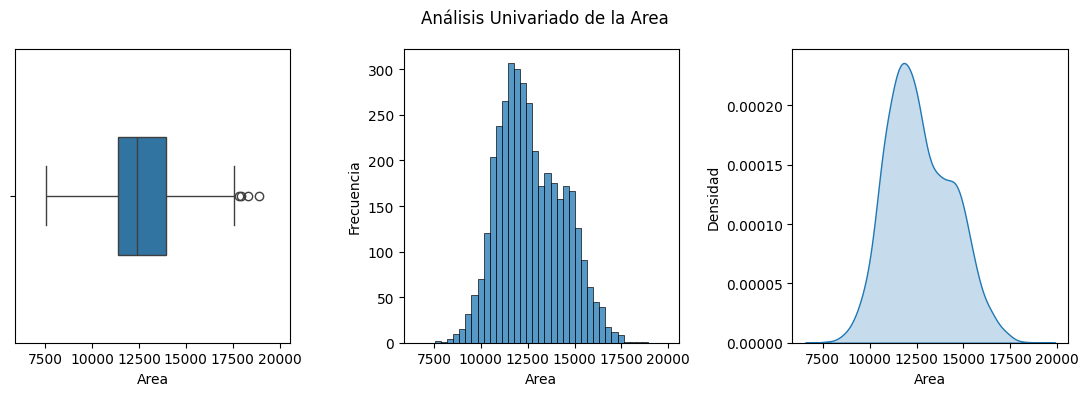

In [10]:
var = 'Area'
var_title = 'Area'

# Ajustes de la figura de Matplotlib
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(11, 4), sharex=True)

# Plotea el boxplot
sns.boxplot(data=dfRice[var], ax=ax[0], orient='h', width=0.4)
ax[0].set_xlabel(var_title)

# Plotea el histograma
sns.histplot(data=dfRice[var], ax=ax[1], kde=False)
ax[1].set_xlabel(var_title)
ax[1].set_ylabel('Frecuencia')

# Plotea la curva de densidad
sns.kdeplot(data=dfRice[var], ax=ax[2], fill=True)
ax[2].set_xlabel(var_title)
ax[2].set_ylabel('Densidad')

fig.suptitle('Análisis Univariado de la ' + var_title)

plt.tight_layout()

El área tiene algunos valores outliers por lo que podría ser conveniente eliminarlos

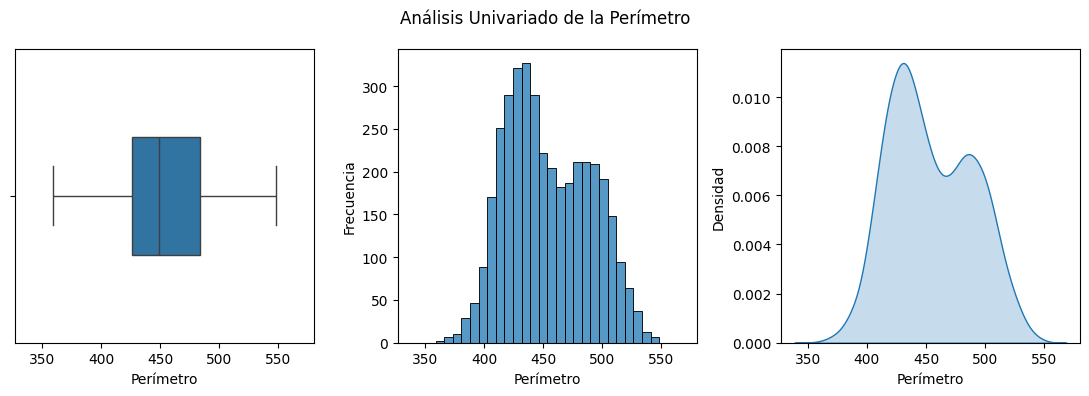

In [11]:
var = 'Perimetro'
var_title = 'Perímetro'

# Ajustes de la figura de Matplotlib
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(11, 4), sharex=True)

# Plotea el boxplot
sns.boxplot(data=dfRice[var], ax=ax[0], orient='h', width=0.4)
ax[0].set_xlabel(var_title)

# Plotea el histograma
sns.histplot(data=dfRice[var], ax=ax[1], kde=False)
ax[1].set_xlabel(var_title)
ax[1].set_ylabel('Frecuencia')

# Plotea la curva de densidad
sns.kdeplot(data=dfRice[var], ax=ax[2], fill=True)
ax[2].set_xlabel(var_title)
ax[2].set_ylabel('Densidad')

fig.suptitle('Análisis Univariado de la ' + var_title)

plt.tight_layout()

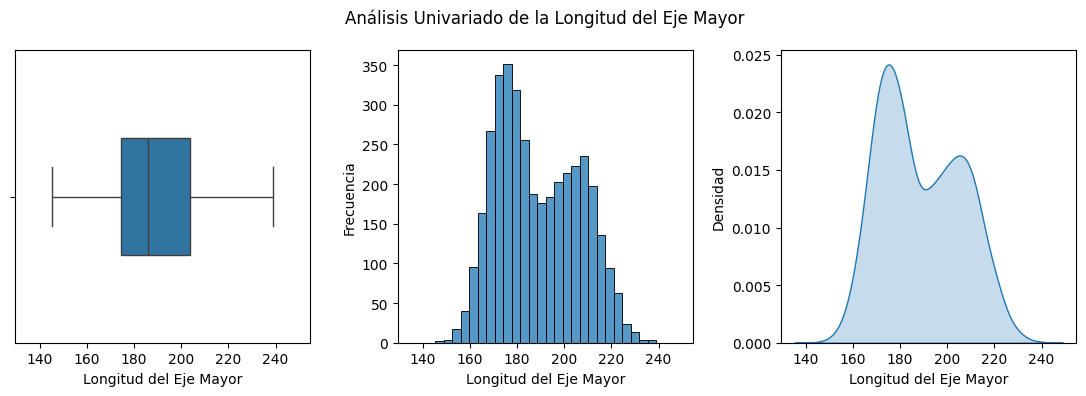

In [12]:
var = 'Longitud_Eje_Mayor'
var_title = 'Longitud del Eje Mayor'

# Ajustes de la figura de Matplotlib
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(11, 4), sharex=True)

# Plotea el boxplot
sns.boxplot(data=dfRice[var], ax=ax[0], orient='h', width=0.4)
ax[0].set_xlabel(var_title)

# Plotea el histograma
sns.histplot(data=dfRice[var], ax=ax[1], kde=False)
ax[1].set_xlabel(var_title)
ax[1].set_ylabel('Frecuencia')

# Plotea la curva de densidad
sns.kdeplot(data=dfRice[var], ax=ax[2], fill=True)
ax[2].set_xlabel(var_title)
ax[2].set_ylabel('Densidad')

fig.suptitle('Análisis Univariado de la ' + var_title)

plt.tight_layout()

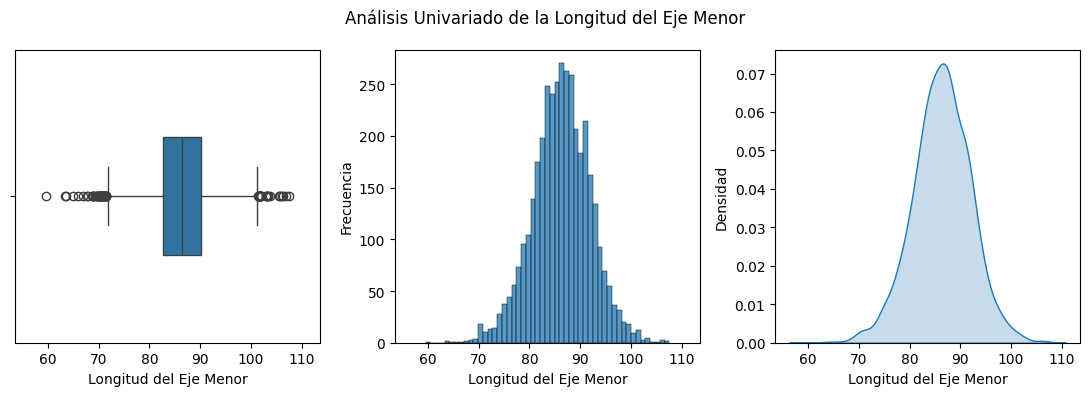

In [13]:
var = 'Longitud_Eje_Menor'
var_title = 'Longitud del Eje Menor'

# Ajustes de la figura de Matplotlib
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(11, 4), sharex=True)

# Plotea el boxplot
sns.boxplot(data=dfRice[var], ax=ax[0], orient='h', width=0.4)
ax[0].set_xlabel(var_title)

# Plotea el histograma
sns.histplot(data=dfRice[var], ax=ax[1], kde=False)
ax[1].set_xlabel(var_title)
ax[1].set_ylabel('Frecuencia')

# Plotea la curva de densidad
sns.kdeplot(data=dfRice[var], ax=ax[2], fill=True)
ax[2].set_xlabel(var_title)
ax[2].set_ylabel('Densidad')

fig.suptitle('Análisis Univariado de la ' + var_title)

plt.tight_layout()

Longitud del Eje Menor tiene valores outliers. PCA se ve afectado por este tipo de valores por lo tanto pdría ser conveniente eliminarlos.

## Análisis Multivariado

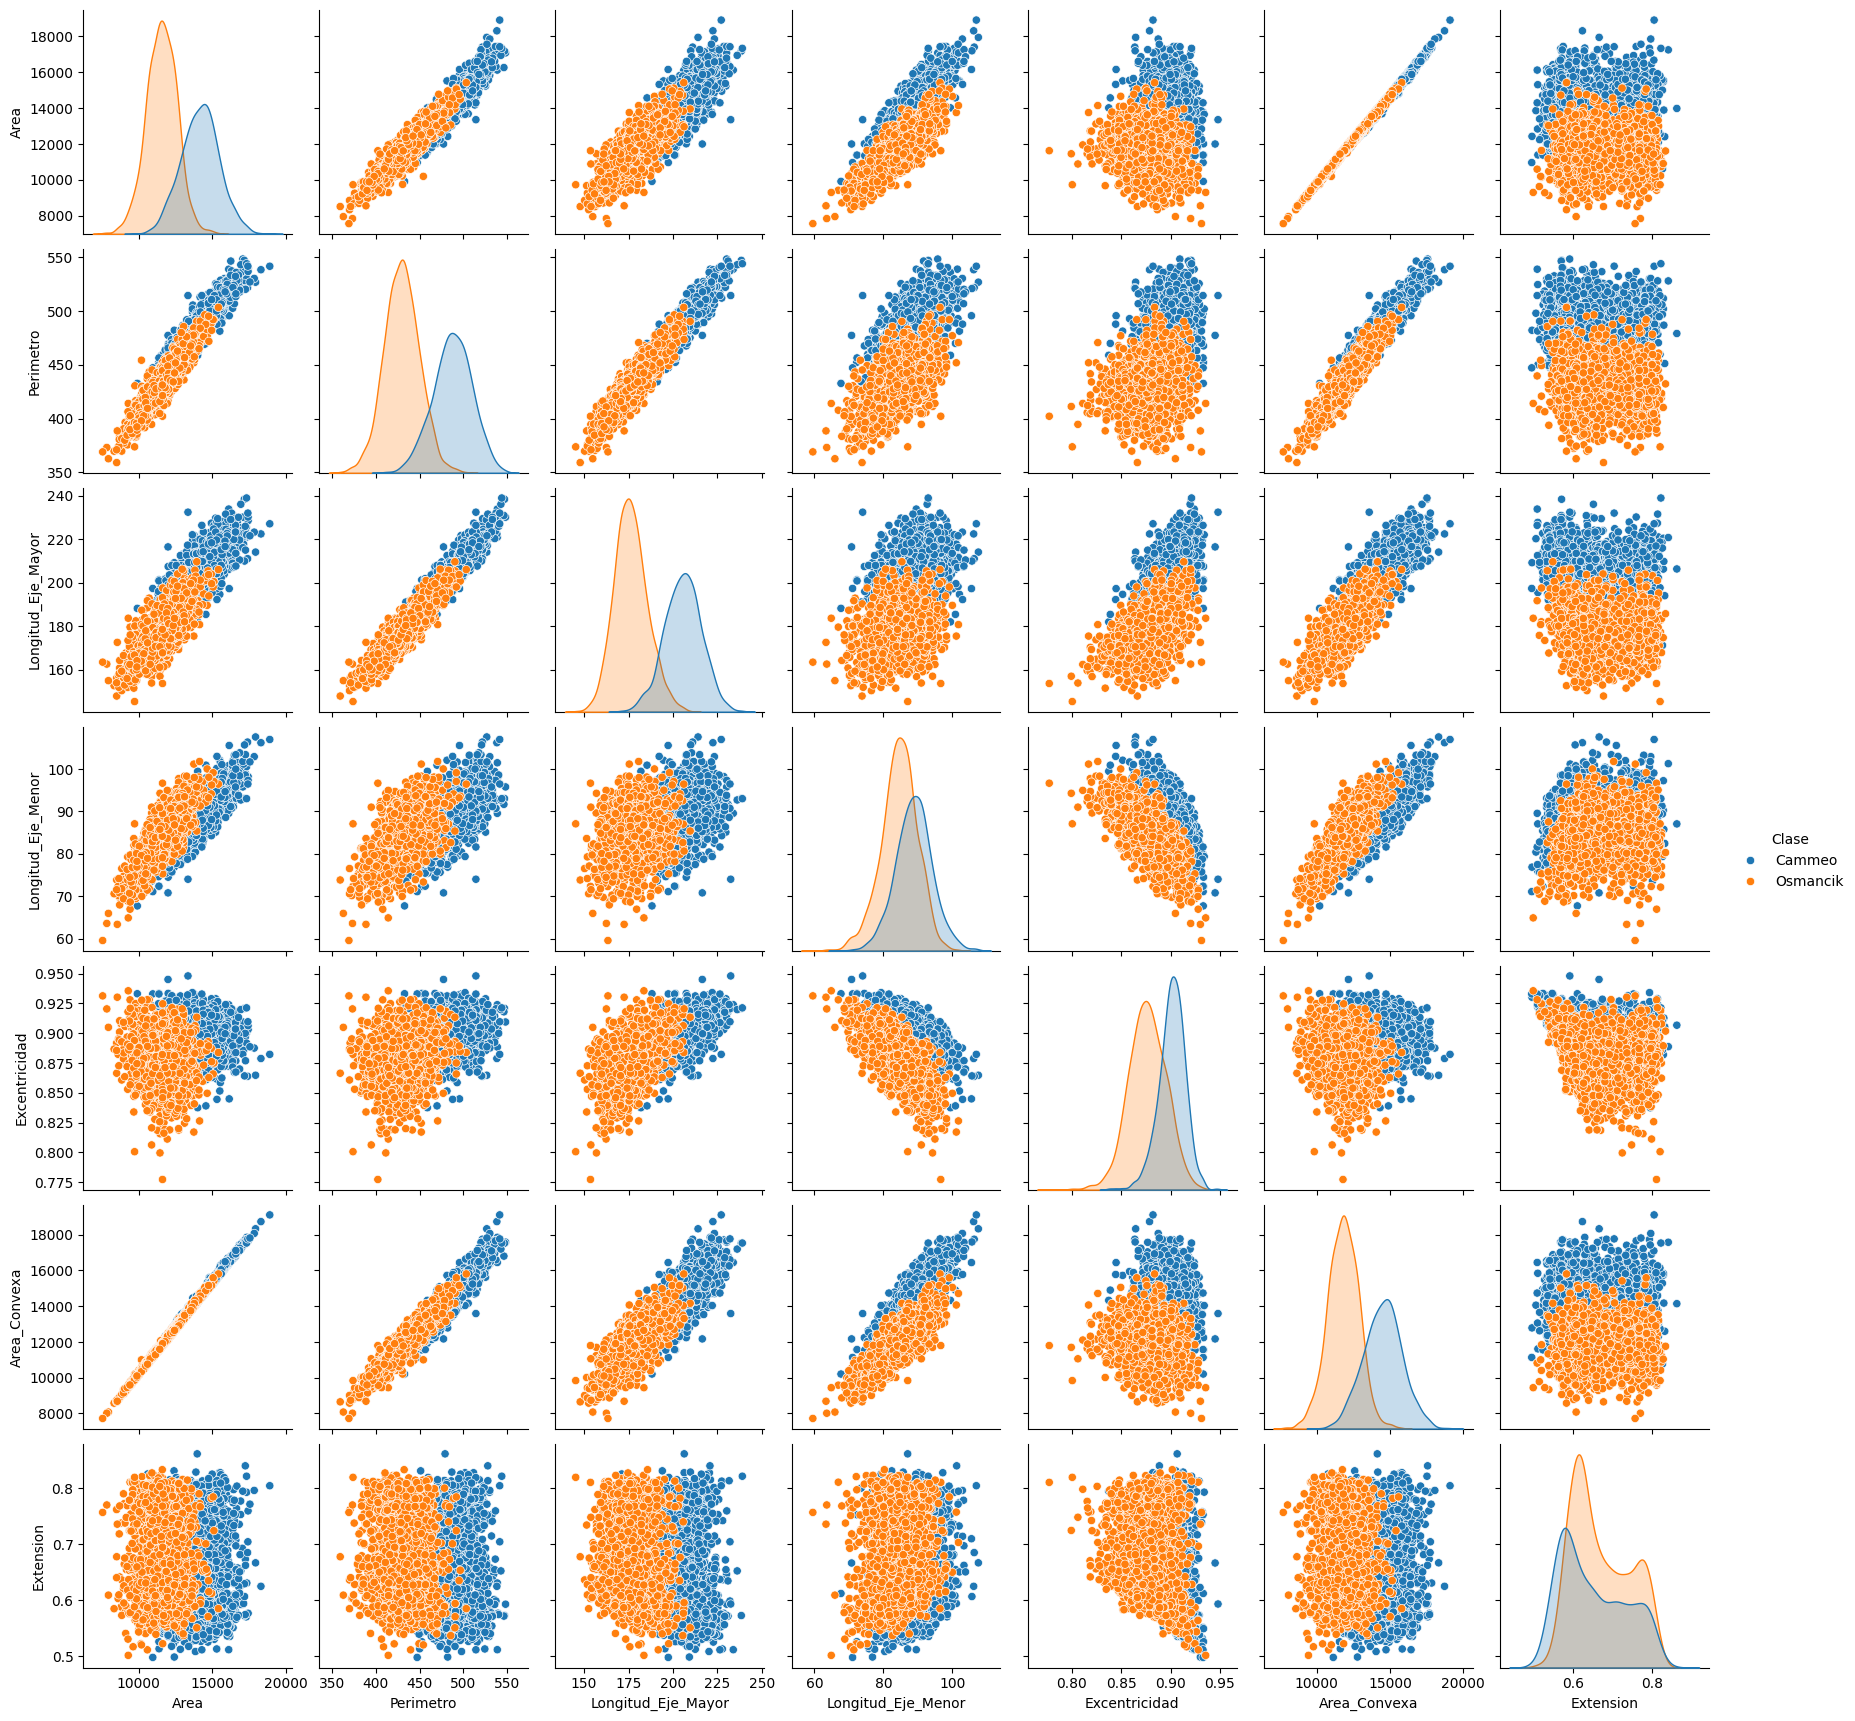

In [14]:
sns.pairplot(dfRice, hue="Clase", diag_kind="kde")

Observamos que existe una fuerte relación lineal entre área, perímetro y las longitudes de los ejes.
Esto confirma que las variables están correlacionadas, y por lo tanto, PCA puede ser muy útil para representar toda esa información redundante con un número menor de dimensiones.
Si todas las variables fueran completamente independientes, el PCA no aportaría tanto valor.

# Estandarización

Aplicaremos PCA sólo a los valores númericos por lo tanto separaremos la variable Clase y estandarizaremos los valores de las variables a reducir.



---

Las variables tienen escalas distintas (por ejemplo, el área puede medirse en miles, mientras que la excentricidad es un número entre 0 y 1).
Como el PCA se basa en la variación de los valores, las variables de mayor escala dominarían el análisis.
Por eso, debemos estandarizarlas, es decir, convertir todas a una escala comparable (media 0, desviación estándar 1).



In [15]:
y = dfRice['Clase'] #Separo la variable categórica

X_df = dfRice.drop(['Clase'],axis=1) #dejo todas las variables excepto la categórica
ss = StandardScaler()
ss.fit(X_df) # calculo la media para poder hacer la transformacion
X_scaled=ss.transform(X_df) #Escala los datos y los normalizo
print(X_scaled)

[[ 1.47982953  2.0043543   2.34854657 ...  2.01833745  1.49965944
  -1.15292093]
 [ 1.14787029  1.12585309  0.98839042 ...  0.41001816  1.19291767
  -0.60207877]
 [ 1.13516924  1.31721425  1.45190846 ...  1.2129565   1.12650386
   0.405611  ]
 ...
 [-0.13320373 -0.32985087 -0.29824512 ... -0.27509916 -0.17306812
  -0.45573108]
 [-1.60825742 -1.74032002 -1.58097116 ... -0.59882134 -1.60715621
  -0.03716757]
 [-0.71225612 -1.39156604 -1.58754648 ... -2.93916013 -0.76628981
   1.82594692]]


# Contrucción del modelo




En esta etapa, ajustamos el modelo de PCA utilizando las 7 variables numéricas estandarizadas.

Primero usamos tantas componentes como variables, y luego evaluamos cuánta información aporta cada una para decidir cuántas conservar.
Cada componente es una combinación lineal de las variables originales, y se ordenan según la cantidad de varianza que explican.



---



**Decisión sobre los outliers:**

Durante el análisis univariado se observaron algunos valores atípicos (outliers) en variables como el Área y la Longitud del eje menor.
Sin embargo, la cantidad de observaciones extremas fue muy pequeña en relación con el total del conjunto de datos (3810 registros), y no se identificaron valores claramente erróneos o imposibles desde el punto de vista físico.

Por ese motivo, no se eliminaron.
Mantenerlos permite conservar la integridad del dataset original y evitar una reducción innecesaria de información.

Además, dado que el PCA es relativamente robusto cuando los outliers son escasos y no extremos, su presencia no debería afectar significativamente la dirección de las componentes principales.

In [18]:
pca7 = PCA(n_components = 7)
datosproyectados = pca7.fit_transform(X_scaled)
datosproyectados.shape

(3810, 7)

**Análisis linea por linea:**

---


**pca7 = PCA(n_components = 7)**

Esta línea crea el modelo de PCA, importado desde sklearn.decomposition.

El parámetro principal que se define es n_components, que indica cuántas componentes principales queremos calcular (o conservar).

👉 Estamos pidiendo que el modelo calcule 7 componentes principales, que coincide con la cantidad de variables originales (porque el dataset tiene 7 columnas numéricas).

📌 Importante:

Al poner el mismo número de componentes que de variables, no se reduce la dimensionalidad, pero sí se puede medir cuánta información aporta cada una.

Luego, al analizar la varianza explicada acumulada, vamos a poder decidir si realmente se necesitan las 7 o si con 2 o 3 alcanza.

💡 Otros valores posibles:

* n_components = 2 →  da solo las dos primeras componentes (útil para graficar en 2D).

* n_components = 0.95 → "decírle" al modelo que elija automáticamente el número mínimo de componentes que expliquen al menos el 95% de la varianza total.

* n_components = None (valor por defecto) → calcula todas las posibles componentes.

n_components puede ser un número entero o una proporción (por ejemplo, 0.95)

---

**pca7.fit_transform(X_scaled)**

Esta línea entrena el modelo PCA y transforma los datos al mismo tiempo.
* fit: El modelo “aprende” hacia qué ejes debe rotar el sistema de coordenadas para que los datos queden más “extendidos” en las nuevas direcciones.

* transform: una vez aprendidas esas direcciones, proyecta los datos originales sobre esos nuevos ejes.

El resultado son los datos transformados en el nuevo espacio de componentes principales.

El resultado se guarda en datosproyectados



---



**datosproyectados = pca7.fit_transform(X_scaled)**

Será una nueva matriz con las mismas 3810 observaciones, pero expresadas en términos de las componentes principales.



---

**datosproyectados.shape**

Esta línea simplemente muestra la dimensión de la nueva matriz.

Como usamos n_components = 7, el resultado será (3810, 7) Es decir: 3810 filas (una por cada grano de arroz) y 7 columnas (una por cada componente principal)

Si hubieramos elegido n_components = 3, sería (3810, 3) lo que significa que condensamos toda la información de 7 variables en solo 3 dimensiones.


# Varianza explicada y selección de componentes

**¿Por qué usamos las 7 componentes y luego elegimos menos?**

Inicialmente, ajustamos el modelo de PCA utilizando las 7 variables numéricas, lo que nos da 7 componentes principales. Esto nos permite observar **cuánta varianza explica cada componente**, es decir, cuánta información del conjunto original captura cada una.

Posteriormente, aplicamos el **método del codo**, una técnica visual que nos ayuda a decidir **cuántas componentes conservar**. La idea es identificar el punto a partir del cual agregar más componentes aporta una mejora mínima en la varianza explicada.

Nuestro objetivo es conservar el menor número de componentes que expliquen la mayor parte de la variabilidad. En este caso, observamos que con **solo 3 componentes** ya se explica más del **99% de la varianza total**, por lo que podemos reducir de 7 dimensiones a solo 3 sin perder información significativa.


In [20]:
acum = 0
for comp in range(0,7):
  acum = acum +  pca7.explained_variance_ratio_ [comp]
  print('Componente Principal ', comp+1, ':', pca7.explained_variance_ratio_ [comp], 'Var Ratio Acumulado: ', acum )

Componente Principal  1 : 0.654139893947999 Var Ratio Acumulado:  0.654139893947999
Componente Principal  2 : 0.21425123840020985 Var Ratio Acumulado:  0.8683911323482089
Componente Principal  3 : 0.12868648649970993 Var Ratio Acumulado:  0.9970776188479188
Componente Principal  4 : 0.0016794016172538137 Var Ratio Acumulado:  0.9987570204651726
Componente Principal  5 : 0.0008880935749359819 Var Ratio Acumulado:  0.9996451140401086
Componente Principal  6 : 0.00029323773372328586 Var Ratio Acumulado:  0.9999383517738318
Componente Principal  7 : 6.16482261682756e-05 Var Ratio Acumulado:  1.0


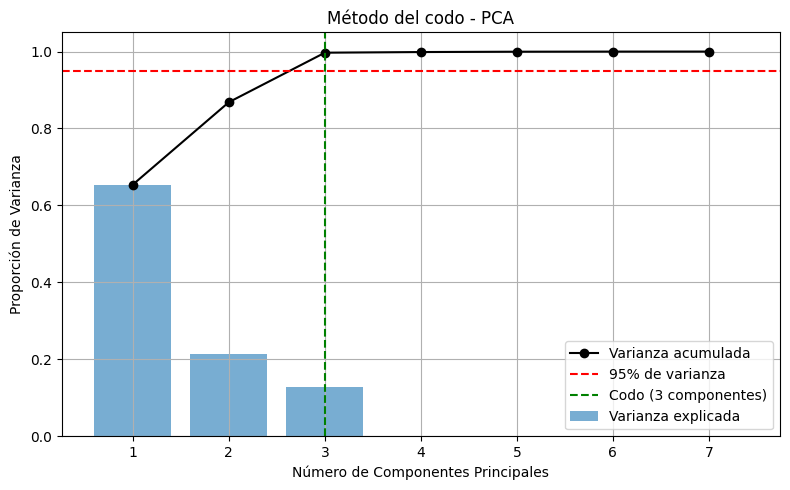

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# Varianza explicada
varianza = pca7.explained_variance_ratio_
var_acumulada = np.cumsum(varianza)

plt.figure(figsize=(8, 5))
plt.bar(range(1, len(varianza)+1), varianza, alpha=0.6, label='Varianza explicada')
plt.plot(range(1, len(var_acumulada)+1), var_acumulada, marker='o', label='Varianza acumulada', color='black')
plt.axhline(y=0.95, color='red', linestyle='--', label='95% de varianza')
plt.axvline(x=3, color='green', linestyle='--', label='Codo (3 componentes)')

plt.title('Método del codo - PCA')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Proporción de Varianza')
plt.xticks(range(1, len(varianza)+1))
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# Interpretación de los componentes

El atributo components_ muestra las cargas o pesos de cada variable original dentro de cada componente principal.

Estos valores indican qué variables tienen más influencia en cada eje.
Por ejemplo, si el primer componente tiene altos valores en “Área”, “Perímetro” y “Longitud del eje mayor”, podemos interpretarla como una medida general del tamaño del grano.

Esto convierte las 7 variables originales en unas pocas dimensiones interpretables.

In [21]:
# Ver las cargas de cada variable en los componentes principales
variablesEnComponentes = pca7.components_



print("\nCargas (loadings) de cada componente principal:")
dfvariablesEnComponentes = pd.DataFrame(variablesEnComponentes, columns=X_df.columns)
print(dfvariablesEnComponentes)


Cargas (loadings) de cada componente principal:
       Area  Perimetro  Longitud_Eje_Mayor  Longitud_Eje_Menor  Excentricidad  \
0  0.461252   0.464408            0.447076            0.321752       0.227329   
1 -0.124377   0.055751            0.213456           -0.567105       0.673152   
2 -0.012611   0.028372            0.121555           -0.212716       0.297985   
3 -0.334695   0.688857            0.240547           -0.327928      -0.482205   
4  0.372024  -0.475356            0.525727           -0.427231      -0.409286   
5  0.194288   0.125758           -0.581697           -0.475724      -0.078042   
6  0.695304   0.253200           -0.259152           -0.115078      -0.016306   

   Area_Convexa  Extension  
0      0.461694  -0.057716  
1     -0.122535  -0.382232  
2     -0.016879   0.921918  
3     -0.122948   0.020451  
4      0.094890  -0.014147  
5      0.612909   0.002166  
6     -0.609723   0.003443  


# Visualización tridimensional

Ahora proyectamos los datos sobre las tres primeras componentes principales y los visualizamos en un gráfico 3D interactivo.

Cada punto representa un grano de arroz, y el color indica su clase.

Si observamos que los grupos se separan visualmente, significa que las variables medidas contienen información suficiente para distinguir las clases incluso sin usar un modelo de clasificación.

In [24]:
CP1 = datosproyectados[:, 0]
CP2 = datosproyectados[:, 1]
CP3 = datosproyectados[:, 2]

fig = px.scatter_3d(x=CP1, y=CP2, z=CP3, color=dfRice['Clase'], opacity = 0.9)
fig.show()

# Conclusión final

En este análisis aplicamos PCA sobre el dataset de granos de arroz para reducir la dimensionalidad y explorar su estructura interna. Comenzamos calculando las 7 componentes principales, correspondientes a las 7 variables originales, con el objetivo de conocer cuánta información aporta cada una.

Luego, aplicamos el **método del codo**, que nos permitió determinar de forma visual el punto de corte óptimo. Descubrimos que **con solo 3 componentes principales se explica más del 99% de la varianza total**, lo cual nos permite simplificar el conjunto de datos sin perder información relevante.

Esta reducción facilitó la **visualización tridimensional**, en la que observamos una clara separación entre las clases de arroz, lo que indica que las variables morfológicas medidas son efectivas para distinguir variedades.

En síntesis, el PCA actuó como una herramienta exploratoria que nos permitió:
- Eliminar redundancia.
- Visualizar mejor los datos.
- Comprender la estructura interna del conjunto.

Es importante destacar que **PCA no es el objetivo final, sino un paso clave** que abre el camino hacia análisis más profundos, como la construcción de modelos de clasificación, o la comparación con otras técnicas de reducción de dimensionalidad como **t-SNE** o **LDA**, según el propósito del análisis.
